# Images to a classifier with Variopinta

Explore Imagenette, try a few augmentations, replay them by key, and train a classifier with [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/common/lightning_module.html).

Download this notebook and **Run All** in a fresh Python 3.12 or 3.13 Jupyter kernel with a CUDA GPU. The first cell installs the packages with pip; no repository checkout or companion download is needed. Imagenette is downloaded once and cached. Set `SMOKE = True` for a short GPU run using the same four-worker loaders.

In [1]:
%pip install -q --upgrade variopinta pytorch-lightning==2.6.1 torchmetrics==1.8.2 torch==2.9.1 torchvision==0.24.1 numpy==2.2.6 matplotlib==3.10.8 pillow==12.1.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
import logging
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import variopinta as vp
from torch.utils.data import DataLoader
from torchvision.datasets import Imagenette
from torchvision.models import resnet50

SMOKE = False
CACHE = Path.home() / ".cache" / "variopinta-imagenette"
WORKERS = 4
SEED, SIZE, BATCH_SIZE = 42, 128, 64
EPOCHS = 1 if SMOKE else 10
LR, WEIGHT_DECAY = 0.001, 0.01
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

if not torch.cuda.is_available():
    raise RuntimeError("Select a CUDA GPU kernel/runtime to run this notebook.")
CACHE.mkdir(parents=True, exist_ok=True)
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
pl.seed_everything(SEED)
plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 10})
print(f"Variopinta {version('variopinta')} · Lightning {pl.__version__} · Torch {torch.__version__}")

Seed set to 42


Variopinta 0.4.4 · Lightning 2.6.1 · Torch 2.9.1+cu128


## Get a few images

Torchvision's [Imagenette dataset](https://docs.pytorch.org/vision/0.24/generated/torchvision.datasets.Imagenette.html) handles downloading, checking the archive, extraction, and cache reuse. `loader=str` gives us file paths: Variopinta will decode the JPEGs itself.

In [3]:
train_files = Imagenette(CACHE, split="train", size="320px", download=True, loader=str)
valid_files = Imagenette(CACHE, split="val", size="320px", loader=str)
train_samples, valid_samples = sorted(train_files), sorted(valid_files)
class_names = [names[0] for names in train_files.classes]
assert train_files.wnid_to_idx == valid_files.wnid_to_idx

9,469 training images · 3,925 validation images · 10 classes


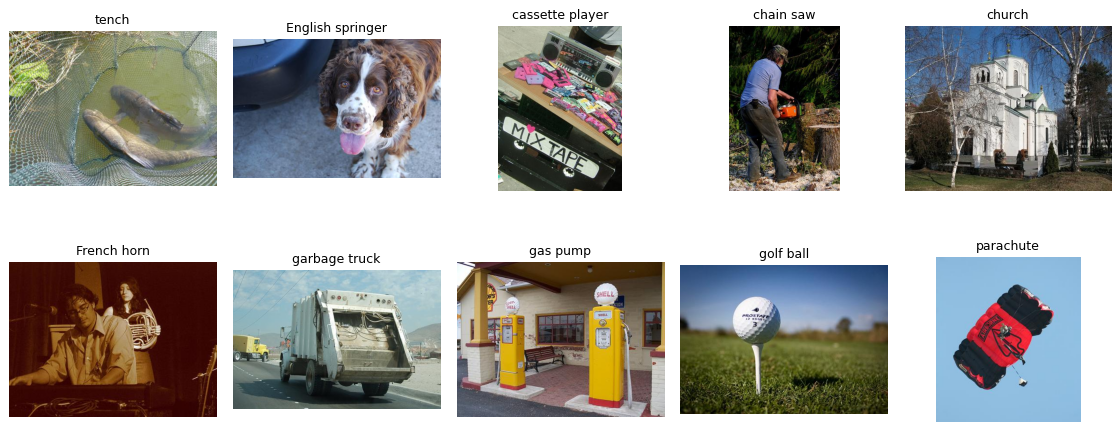

In [4]:
print(
    f"{len(train_samples):,} training images · {len(valid_samples):,} validation images · {len(class_names)} classes"
)

def grid(images, titles, columns=5, height=2.5):
    rows = (len(images) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(columns * 2.5, rows * height), squeeze=False)
    for ax, image, title in zip(axes.flat, images, titles, strict=False):
        ax.imshow(image)
        ax.set_title(title)
    for ax in axes.flat:
        ax.axis("off")
    fig.subplots_adjust(hspace=0.4, wspace=0.08, top=0.9, bottom=0.02, left=0.01, right=0.99)
    plt.show()


examples = [next(path for path, label in train_samples if label == i) for i in range(10)]
originals = [vp.read_image(path) for path in examples]
grid(originals, class_names)

## Try some transformations

These examples display RGB pixels **before normalization**. Crop and flip will be used for training; color jitter and blur are just demonstrations. Resize and crop use bilinear interpolation with antialiasing.

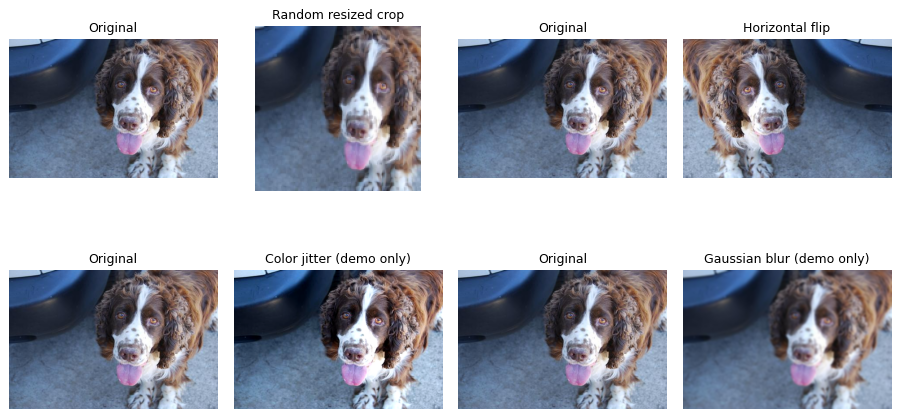

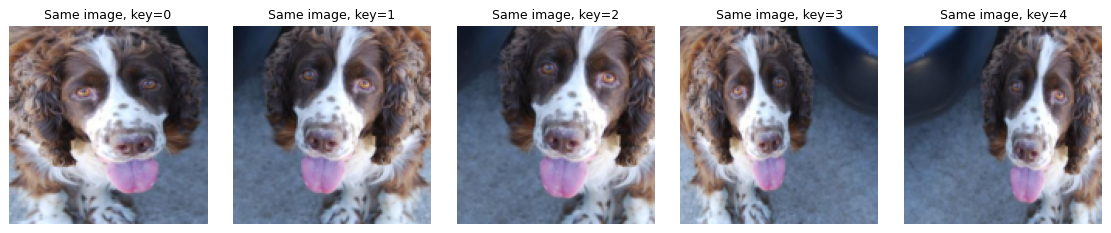

In [5]:
original = originals[1]
demos = {
    "Random resized crop": vp.RandomResizedCrop(
        SIZE,
        SIZE,
        scale=(0.35, 1.0),
        ratio=(0.75, 4 / 3),
        interpolation=vp.Interpolation.BILINEAR,
        antialias=True,
    ),
    "Horizontal flip": vp.HorizontalFlip(p=1.0),
    "Color jitter (demo only)": vp.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.4, hue=0.05
    ),
    "Gaussian blur (demo only)": vp.GaussianBlur(kernel_size=9, sigma=2.0),
}
images, titles = [], []
for title, transform in demos.items():
    pipeline = vp.Pipeline([transform], seed=SEED).compile()
    images.extend([original, pipeline(original, key=7)])
    titles.extend(["Original", title])
grid(images, titles, columns=4)

visual_policy = vp.Pipeline(
    [demos["Random resized crop"], vp.HorizontalFlip(p=0.5)], seed=SEED
).compile()
grid([visual_policy(original, key=k) for k in range(5)], [f"Same image, key={k}" for k in range(5)])

## Replay an augmentation

A pipeline seed and a per-image `key` let you repeat an augmentation even when calls arrive in a different order. Keep the image, pipeline, seed, key, and Variopinta build/environment fixed for exact replay.

In [6]:
first = visual_policy(original, key=17)
for key in [91, 3, 0, 91]:
    visual_policy(original, key=key)
assert np.array_equal(first, visual_policy(original, key=17))
print("The same key reproduced exactly the same pixels.")

The same key reproduced exactly the same pixels.


## Inspect a compiled pipeline

`explain()` describes a static execution plan. Here the compiled resize borrows the input and avoids the reference executor's initial copy. Both produce the same result; this is plan inspection, not a timing measurement.

In [7]:
reference = vp.Pipeline([vp.Resize(SIZE, SIZE, antialias=True)], seed=SEED)
compiled = reference.compile()
assert np.array_equal(reference(original, key=0), compiled(original, key=0))
for pipeline in (reference, compiled):
    plan = pipeline.explain()
    print(
        plan["mode"],
        {name: plan["steps"][0][name] for name in ("input_materialization", "kernel_form")},
    )

reference {'input_materialization': 'owned-input-copy', 'kernel_form': 'owned-to-owned'}
compiled {'input_materialization': 'borrowed-input', 'kernel_form': 'borrowed-to-owned'}


## Make training tensors

Build the compiled pipelines before starting workers: JPEG decode, augmentation, one ImageNet normalization, and contiguous CHW `float32` CPU tensors. Lightning will move batches to the GPU.

The next `%%writefile` cell makes the Dataset and sampler importable by `spawn` workers, using ordinary Python. Standard pickle transfers the Dataset's compiled pipeline and preserves its shared image/output ports. Loading reconstructs native execution automatically.

Lightning updates the sampler's epoch. Each request carries `(epoch, index)`, so persistent workers receive the right key: `epoch * len(samples) + index`. Validation uses a stable sample key and a plain 128 × 128 resize.

In [8]:
%%writefile imagenette_dataset.py
import torch
from torch.utils.data import Dataset, Sampler


class AugmentedImages(Dataset):
    def __init__(self, samples, pipeline, training=False):
        self.samples, self.pipeline, self.training = samples, pipeline, training
        self.image = pipeline.targets[0]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, request):
        epoch, index = request if isinstance(request, tuple) else (0, request)
        path, label = self.samples[index]
        key = epoch * len(self.samples) + index if self.training else index
        tensor = self.pipeline(image=self.image.bind(path), key=key).image.tensor
        return tensor, label


class EpochSampler(Sampler):
    def __init__(self, indices, seed):
        self.indices, self.seed, self.epoch = list(indices), seed, 0

    def __len__(self):
        return len(self.indices)

    def set_epoch(self, epoch):
        self.epoch = epoch

    def __iter__(self):
        rng = torch.Generator().manual_seed(self.seed + self.epoch)
        order = torch.randperm(len(self.indices), generator=rng).tolist()
        return iter((self.epoch, self.indices[i]) for i in order)

Overwriting imagenette_dataset.py


In [9]:
from imagenette_dataset import AugmentedImages, EpochSampler

image_target = vp.Image(carrier=vp.Path(), outputs=vp.ReturnTensor(name="tensor"), name="image")
train_pipeline = vp.Pipeline(
    [
        vp.RandomResizedCrop(SIZE, SIZE, scale=(0.35, 1.0), antialias=True),
        vp.HorizontalFlip(p=0.5),
        vp.Normalize(mean=MEAN, std=STD),
    ],
    seed=SEED,
    targets=image_target,
).compile()
valid_pipeline = vp.Pipeline(
    [vp.Resize(SIZE, SIZE, antialias=True), vp.Normalize(mean=MEAN, std=STD)],
    seed=SEED,
    targets=image_target,
).compile()
train_ds = AugmentedImages(train_samples, train_pipeline, training=True)
valid_ds = AugmentedImages(valid_samples, valid_pipeline)

image, label = train_ds[0]
assert image.shape == (3, SIZE, SIZE) and image.dtype == torch.float32 and image.is_contiguous()
assert torch.equal(image, train_ds[0][0])
print(f"One sample: {tuple(image.shape)}, {image.dtype}, {class_names[label]}")

One sample: (3, 128, 128), torch.float32, tench


In [10]:
train_sampler = EpochSampler(range(len(train_ds)), SEED)
loader_options = dict(
    batch_size=BATCH_SIZE,
    num_workers=WORKERS,
    multiprocessing_context="spawn",
    persistent_workers=True,
    pin_memory=True,
)
train_loader = DataLoader(train_ds, sampler=train_sampler, **loader_options)
valid_loader = DataLoader(valid_ds, shuffle=False, **loader_options)
print(f"{WORKERS} persistent spawn workers per loader · batch size {BATCH_SIZE}")

4 persistent spawn workers per loader · batch size 64


## Train with Lightning

We train torchvision's **ResNet-50 from scratch** for ten epochs at batch size 64. The example uses AdamW (`lr=0.001`, weight decay `0.01`), cosine learning-rate decay, and cross entropy with label smoothing `0.1`. Lightning handles device transfers, backpropagation, and validation. No additional image transforms or mixed precision are applied.

In [11]:
class Classifier(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = resnet50(weights=None, num_classes=10)
        self.loss = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
        self.history = []

    def forward(self, images):
        return self.model(images)

    def on_train_epoch_start(self):
        assert train_sampler.epoch == self.current_epoch, "Lightning must advance the sampler epoch."

    def training_step(self, batch, batch_idx):
        images, labels = batch
        loss = self.loss(self(images), labels)
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        logits = self(images)
        self.log("valid_loss", self.loss(logits, labels))
        self.log("accuracy", (logits.argmax(1) == labels).float().mean())

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
        return [optimizer], [scheduler]

    def on_train_epoch_end(self):
        metrics = {name: value.item() for name, value in self.trainer.callback_metrics.items()}
        assert all(np.isfinite(value) for value in metrics.values())
        self.history.append(metrics)
        print(
            f"Epoch {self.current_epoch + 1}: train loss {metrics['train_loss']:.3f}, "
            f"valid loss {metrics['valid_loss']:.3f}, accuracy {metrics['accuracy']:.1%}"
        )

In [12]:
pl.seed_everything(SEED)
classifier = Classifier()
trainer = pl.Trainer(
    max_epochs=EPOCHS,
    accelerator="gpu",
    devices=1,
    precision="32-true",
    logger=False,
    enable_checkpointing=False,
    enable_progress_bar=False,
    enable_model_summary=False,
    num_sanity_val_steps=0,
    limit_train_batches=3 if SMOKE else 1.0,
    limit_val_batches=2 if SMOKE else 1.0,
)
print("Training on", torch.cuda.get_device_name(0))
trainer.fit(classifier, train_loader, valid_loader)
assert len(classifier.history) == EPOCHS and train_sampler.epoch == EPOCHS - 1
print(f"Completed {EPOCHS} epochs with persistent spawn workers and sample/epoch keys.")

Seed set to 42


Training on NVIDIA GeForce RTX 3090


Epoch 1: train loss 2.072, valid loss 1.846, accuracy 43.0%


Epoch 2: train loss 1.605, valid loss 1.808, accuracy 53.5%


Epoch 3: train loss 1.455, valid loss 1.500, accuracy 61.9%


...

Epoch 7: train loss 1.099, valid loss 1.178, accuracy 74.2%


Epoch 8: train loss 1.031, valid loss 1.115, accuracy 75.9%


Epoch 9: train loss 0.972, valid loss 1.109, accuracy 77.4%


Epoch 10: train loss 0.935, valid loss 1.032, accuracy 79.2%


Completed 10 epochs with persistent spawn workers and sample/epoch keys.


## Look at what it learned

The curves show epoch-average losses and validation top-1 accuracy. The predictions below use validation images; we undo normalization to display their colors.

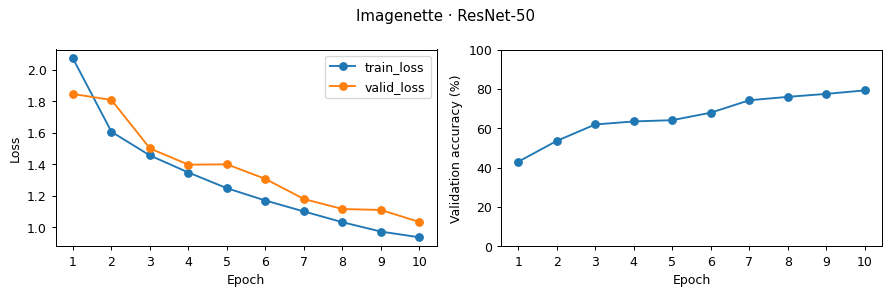

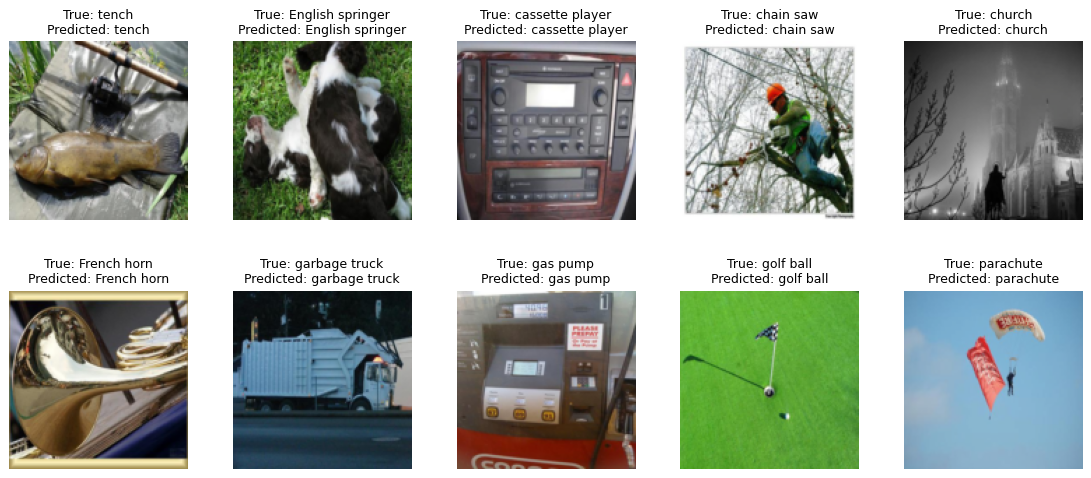

In [13]:
epochs = range(1, len(classifier.history) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
for name in ("train_loss", "valid_loss"):
    axes[0].plot(epochs, [row[name] for row in classifier.history], "o-", label=name)
axes[0].set(xlabel="Epoch", ylabel="Loss")
axes[0].legend()
axes[1].plot(epochs, [100 * row["accuracy"] for row in classifier.history], "o-")
axes[1].set(xlabel="Epoch", ylabel="Validation accuracy (%)", ylim=(0, 100))
for ax in axes:
    ax.set_xticks(list(epochs))
fig.suptitle("GPU smoke" if SMOKE else "Imagenette · ResNet-50")
fig.tight_layout()
plt.show()

indices = [next(i for i, (_, label) in enumerate(valid_samples) if label == j) for j in range(10)]
images = torch.stack([valid_ds[i][0] for i in indices])
classifier.eval()
with torch.inference_mode():
    predictions = classifier(images.to(classifier.device)).argmax(1).cpu().tolist()
rgb = (images.permute(0, 2, 3, 1) * torch.tensor(STD) + torch.tensor(MEAN)).clamp(0, 1).numpy()
titles = [
    f"True: {class_names[valid_samples[i][1]]}\nPredicted: {class_names[pred]}"
    for i, pred in zip(indices, predictions, strict=True)
]
grid(rgb, titles, height=2.7)